# Denoising Autoencoders With Keras

## Checking GPU Usage

Go to the `Runtime > Change runtime type` menu and check that we're on Python 3 and that the hardware accelerator is set to "GPU".

In [1]:
!nvidia-smi

Thu Oct  8 18:33:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4000               On  |   00000000:83:00.0 Off |                  Off |
| 50%   62C    P8             21W /  140W |       1MiB /  16376MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Importing TensorFlow and the Other Required Libraries

In [2]:
import matplotlib.pyplot as plt
import numpy
import tensorflow as tf
import keras

## Loading MNIST

We'll use slightly different preprocessing than usual: since we want to be able to predict the input values at the output (the principle of autoencoding), we'll simply project these values into $[0, 1]$ instead of $[0, 255]$. Note that we usually don't do that: we normalize by centering on zero and dividing by the standard deviation.

In [3]:
(X_train, _), (X_test, y_test) = keras.datasets.mnist.load_data()
nb_classes = 10
input_dim = 28 * 28
X_train = X_train.reshape(-1, input_dim) / 255.0
X_test = X_test.reshape(-1, input_dim) / 255.0

## Applying Gaussian Noise

In [4]:
noise_factor = 0.5
X_train_noisy = X_train + numpy.random.normal(0, noise_factor, X_train.shape)
X_test_noisy = X_test + numpy.random.normal(0, noise_factor, X_test.shape)

# Clip the values to avoid pixels whiter than white (or blacker
# than black)
numpy.clip(X_train_noisy, 0, 1, out=X_train_noisy)
numpy.clip(X_test_noisy, 0, 1, out=X_test_noisy)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.46287927],
       [0.6614468 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.16992068, 0.        , 0.        , ..., 0.        , 0.05964052,
        0.        ],
       ...,
       [1.        , 0.23269813, 0.        , ..., 0.09235017, 0.44706562,
        0.        ],
       [0.24045597, 0.24093795, 0.50870649, ..., 0.        , 0.28225525,
        0.        ],
       [0.        , 0.48018688, 0.74589697, ..., 0.        , 0.        ,
        0.        ]])

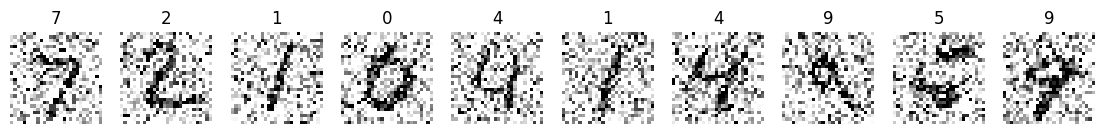

In [5]:
n = 10
f, ax = plt.subplots(1, n, figsize=(n * 1.4, 2))
for i in range(n):
    ax[i].imshow(X_test_noisy[i].reshape(28, 28), cmap="gray_r")
    ax[i].set_title(y_test[i])
    ax[i].axis("off")
plt.show()

## Creating the Denoising Autoencoder

In [6]:
encoding_dim = 4

autoencoder = keras.Sequential(
    [keras.layers.Input(shape=(input_dim,)),
     keras.layers.Dense(encoding_dim, activation="leaky_relu"),
     keras.layers.Dense(input_dim, activation="sigmoid")],
    name="autoencoder")
autoencoder.summary()

autoencoder.compile(optimizer="adam", loss="mean_squared_error")

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │         3,920 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,060 (27.58 KB)

 Trainable params: 7,060 (27.58 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [7]:
autoencoder.fit(X_train_noisy, X_train,
                epochs=50,
                batch_size=256,
                validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0999 - val_loss: 0.0683
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0684 - val_loss: 0.0675
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0671 - val_loss: 0.0652
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0632 - val_loss: 0.0603
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0592 - val_loss: 0.0577
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0573 - val_loss: 0.0563
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0560 - val_loss: 0.0549
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0545 - val_loss: 0.0535
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0535 - val_loss: 0.0527
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0530 - val_loss: 0.0524
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0528 - val_loss: 0.0522
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

## Test Set

In [8]:
X_test_noisy_pred = autoencoder.predict(X_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step


## Visual Display of the Performance

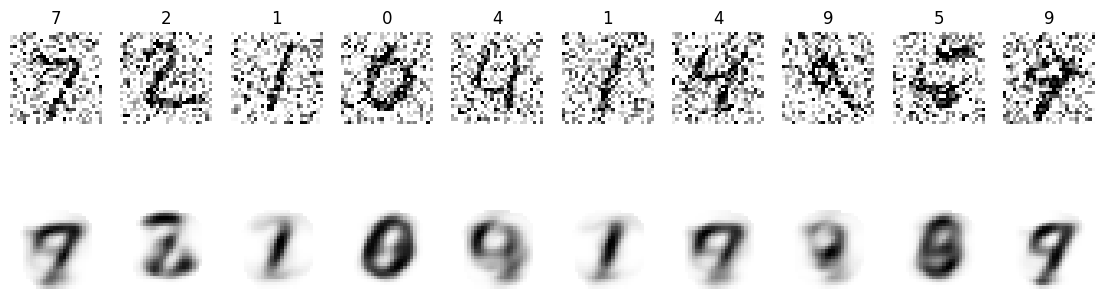

In [9]:
n = 10
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, (ax_top, ax_bottom) in enumerate(ax.T):
    # The original on top
    ax_top.imshow(X_test_noisy[i].reshape(28, 28), cmap="gray_r")
    ax_top.set_title(str(y_test[i]))
    ax_top.axis("off")

    # The reconstruction at the bottom
    ax_bottom.imshow(X_test_noisy_pred[i].reshape(28, 28), cmap="gray_r")
    ax_bottom.axis("off")
plt.show()

## Using Convolutional Networks

To do so, each image must be put back into a 28x28x1 shape. CNNs need this 3rd tensor dimension (there could be more channels than the gray level: there are 3 for color images, and even more in the intermediate layers of a convolutional network, where the number of input channels of a layer is the number of kernels of the previous layer).

In [10]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_train_noisy = X_train_noisy.reshape(-1, 28, 28, 1)
X_test_noisy = X_test_noisy.reshape(-1, 28, 28, 1)

## Creating the Model

We'll use sequences of `Conv2D` and `MaxPool2D` with kernels of 3 x 3 and 2 x 2 respectively for the encoder part. In these two layers, you'll need the `padding="same"` option to avoid border effects (the image being small enough as it is).

For the decoder part, we'll use `Conv2D` layers of the same kind followed by `UpSampling2D((2, 2))` layers, which are the inverse operation of `MaxPool2D`

In [11]:
encoding_dim = 4

autoencoder = keras.Sequential()


def conv(n, activation="leaky_relu"):
  return keras.layers.Conv2D(n, (3, 3), activation=activation, padding="same")


def max_pool():
  return keras.layers.MaxPool2D((2, 2), padding="same")


def up_sampling():
  return keras.layers.UpSampling2D((2, 2))


# Encoding
autoencoder.add(keras.layers.Input(shape=X_train.shape[1:]))
autoencoder.add(conv(32))
autoencoder.add(max_pool())
autoencoder.add(conv(32))
autoencoder.add(max_pool())
autoencoder.add(conv(1))
autoencoder.add(keras.layers.Flatten())
autoencoder.add(keras.layers.Dense(encoding_dim))

# Decoding
autoencoder.add(keras.layers.Dense(49))
autoencoder.add(keras.layers.Reshape((7, 7, 1)))
autoencoder.add(conv(32))
autoencoder.add(up_sampling())
autoencoder.add(conv(32))
autoencoder.add(up_sampling())
autoencoder.add(conv(1, "sigmoid"))

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 1)        │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 49)             │           245 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,159 (78.75 KB)

 Trainable params: 20,159 (78.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [12]:
autoencoder.fit(X_train_noisy, X_train,
                epochs=100,
                batch_size=128,
                validation_split=0.2)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.2734 - val_loss: 0.2311
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2205 - val_loss: 0.2110
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2062 - val_loss: 0.2033
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2006 - val_loss: 0.1993
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1965 - val_loss: 0.1949
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1937 - val_loss: 0.1927
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1919 - val_loss: 0.1912
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1906 - val_loss: 0.1898
Epoch 9/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1893 - val_loss: 0.1892
Epoch 10/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1885 - val_loss: 0.1888
Epoch 11/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1878 - val_loss: 0.1874
Epoch 12/100
375/375 ━━━━━━━━━━━━━━━━━━

## Displaying the Performance

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


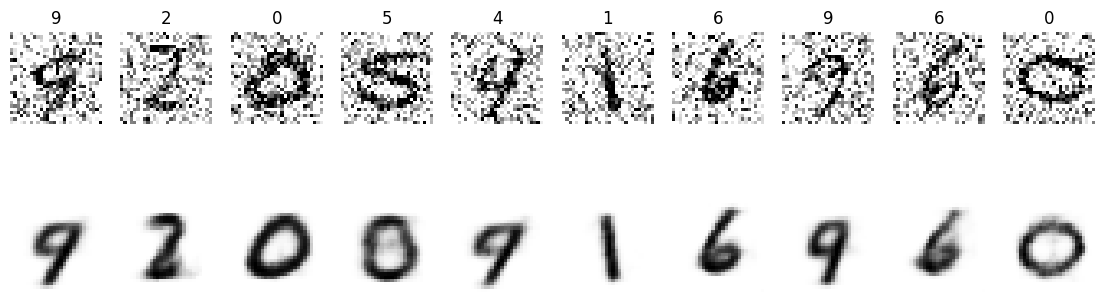

In [13]:
X_test_noisy_pred = autoencoder.predict(X_test_noisy).reshape(-1, 28, 28)

n = 10

random_indexes = numpy.random.choice(X_test.shape[0],
                                     replace=False,
                                     size=n)

_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for (ax_top, ax_bottom), random_index in zip(ax.T, random_indexes):
    # The original image on top
    ax_top.set_title(str(y_test[random_index]))
    ax_top.imshow(X_test_noisy[random_index].reshape(28, 28), cmap="gray_r")
    ax_top.axis("off")

    # The reconstructed image at the bottom
    ax_bottom.imshow(X_test_noisy_pred[random_index], cmap="gray_r")
    ax_bottom.axis("off")
plt.show()

## On Non-Noisy Images

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


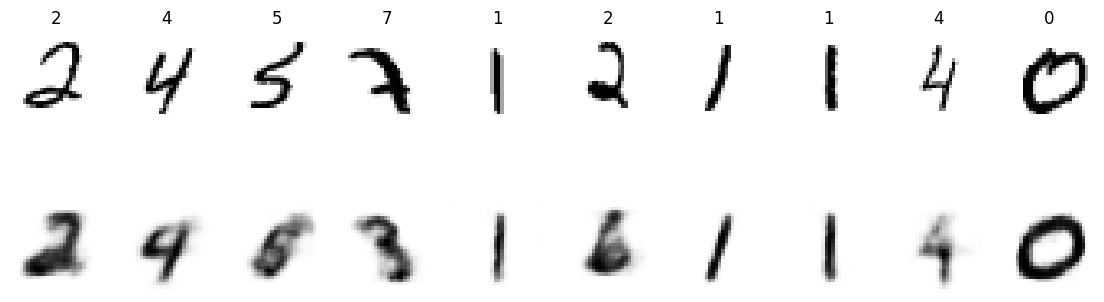

In [14]:
X_test_pred = autoencoder.predict(X_test).reshape(-1, 28, 28)

n = 10

random_indexes = numpy.random.choice(X_test.shape[0],
                                     replace=False,
                                     size=n)

_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for (ax_top, ax_bottom), random_index in zip(ax.T, random_indexes):
    # The original image on top
    ax_top.set_title(str(y_test[random_index]))
    ax_top.imshow(X_test[random_index].reshape(28, 28), cmap="gray_r")
    ax_top.axis("off")

    # The reconstructed image at the bottom
    ax_bottom.imshow(X_test_pred[random_index], cmap="gray_r")
    ax_bottom.axis("off")
plt.show()

## Variational Autoencoders

For VAEs, the training method is much harder to set up, partly because of [the reparameterization trick](https://stats.stackexchange.com/questions/199605/how-does-the-reparameterization-trick-for-vaes-work-and-why-is-it-important)). The Keras maintainers suggest using the following code:

In [15]:
class Sampling(keras.layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [16]:
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(16, activation="relu")(x)
z_mean = keras.layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = keras.layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │     50,192 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = keras.layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = keras.layers.Reshape((7, 7, 64))(x)
x = keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = keras.layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [19]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
vae.fit(X_train, epochs=30, batch_size=128)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - kl_loss: 2.5604 - loss: 212.7993 - reconstruction_loss: 210.2388
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 2.6351 - loss: 184.7711 - reconstruction_loss: 182.1360
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 4.7133 - loss: 168.4850 - reconstruction_loss: 163.7717
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.1663 - loss: 161.7589 - reconstruction_loss: 156.5926
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - kl_loss: 5.3637 - loss: 159.1646 - reconstruction_loss: 153.8009
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.4723 - loss: 157.4720 - reconstruction_loss: 151.9997
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.5564 - loss: 156.2934 - reconstruction_loss: 150.7372
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.6406 - loss: 155.3343 - reconstruction_loss: 149.6938
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms

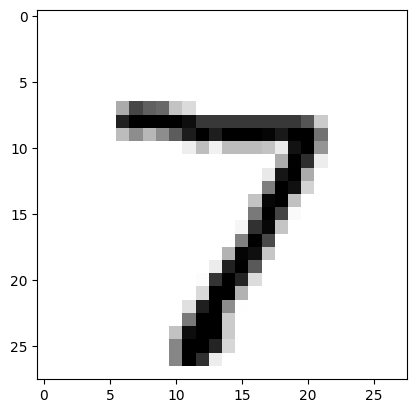

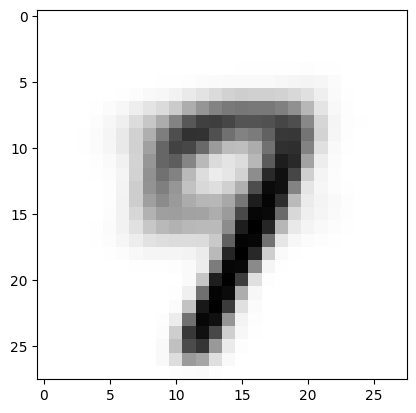

In [20]:
def auto_encode_example(example: numpy.ndarray) -> None:
  x_z_mean, x_z_log_var, x_z = vae.encoder(example[None, ...])
  decoded = vae.decoder(x_z).numpy().squeeze()
  plt.imshow(example.squeeze(), cmap="gray_r")
  plt.show()
  plt.imshow(decoded, cmap="gray_r")
  plt.show()


auto_encode_example(X_test[0])